## 5. Las bases de datos TC_Itau y TC_Itau_label están relacionadas con el uso de tarjeta de crédito de clientes que han sido parte de una campaña de uso, este problema es binario (1) representa a las personas que usaron su tarjeta de crédito y (0) las personas que no lo hicieron, desarrolle el mejor modelo que pueda para clasificar a estos clientres.

### Importar librerias

In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay

### Generamos variables globales

In [2]:
path_main = os.getcwd()
dic_args = {
    'path_data_itau': os.path.join(path_main, '..', 'data', 'TC_Itau.csv'),
    'path_data_itau_lbl': os.path.join(path_main, '..', 'data', 'TC_Itau_label.csv'),
}

### Generamos los DataFrame

In [3]:
schema_data_itau = {
    'Ind_ID': 'int64',
    'GENDER': 'category',
    'Car_Owner': 'category',
    'Propert_Owner': 'category',
    'CHILDREN': 'int8',
    'Annual_income': 'Float64',
    'Type_Income': 'category',
    'EDUCATION': 'category',
    'Marital_status': 'category',
    'Housing_type': object,
    'Birthday_count': 'Float64',
    'Employed_days': 'uint64',
    'Mobile_phone': bool,
    'Work_Phone': bool,
    'Phone': bool,
    'EMAIL_ID': bool,
    'Type_Occupation': object,
    'Family_Members': 'int8',
}

df_itau = pd.read_csv(dic_args['path_data_itau'], dtype=schema_data_itau)

df_itau.info()
df_itau.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1548 entries, 0 to 1547
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   Ind_ID           1548 non-null   int64   
 1   GENDER           1541 non-null   category
 2   Car_Owner        1548 non-null   category
 3   Propert_Owner    1548 non-null   category
 4   CHILDREN         1548 non-null   int8    
 5   Annual_income    1525 non-null   Float64 
 6   Type_Income      1548 non-null   category
 7   EDUCATION        1548 non-null   category
 8   Marital_status   1548 non-null   category
 9   Housing_type     1548 non-null   object  
 10  Birthday_count   1526 non-null   Float64 
 11  Employed_days    1548 non-null   uint64  
 12  Mobile_phone     1548 non-null   bool    
 13  Work_Phone       1548 non-null   bool    
 14  Phone            1548 non-null   bool    
 15  EMAIL_ID         1548 non-null   bool    
 16  Type_Occupation  1060 non-null   object  


,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members
0,5008827,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,365243,True,False,False,False,NaN,2
1,5009744,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,18446744073709551030,True,True,True,False,NaN,2
2,5009746,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,<NA>,18446744073709551030,True,True,True,False,NaN,2
3,5009749,F,Y,N,0,<NA>,Commercial associate,Higher education,Married,House / apartment,-13557.0,18446744073709551030,True,True,True,False,NaN,2
4,5009752,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,18446744073709551030,True,True,True,False,NaN,2


In [4]:
schema_data_lbl = {
    'Ind_ID': 'int64',
    'label': bool
}

df_lbl = pd.read_csv(dic_args['path_data_itau_lbl'], dtype=schema_data_lbl)

df_lbl.info()
df_lbl.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1548 entries, 0 to 1547
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Ind_ID  1548 non-null   int64
 1   label   1548 non-null   bool 
dtypes: bool(1), int64(1)
memory usage: 13.7 KB


,Ind_ID,label
0,5008827,True
1,5009744,True
2,5009746,True
3,5009749,True
4,5009752,True


### Unimos los DF para tener la data completa.

In [5]:
df = df_itau.merge(df_lbl, on='Ind_ID', how='inner')

df.info()
df.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1548 entries, 0 to 1547
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   Ind_ID           1548 non-null   int64   
 1   GENDER           1541 non-null   category
 2   Car_Owner        1548 non-null   category
 3   Propert_Owner    1548 non-null   category
 4   CHILDREN         1548 non-null   int8    
 5   Annual_income    1525 non-null   Float64 
 6   Type_Income      1548 non-null   category
 7   EDUCATION        1548 non-null   category
 8   Marital_status   1548 non-null   category
 9   Housing_type     1548 non-null   object  
 10  Birthday_count   1526 non-null   Float64 
 11  Employed_days    1548 non-null   uint64  
 12  Mobile_phone     1548 non-null   bool    
 13  Work_Phone       1548 non-null   bool    
 14  Phone            1548 non-null   bool    
 15  EMAIL_ID         1548 non-null   bool    
 16  Type_Occupation  1060 non-null   object  


,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,label
0,5008827,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,365243,True,False,False,False,NaN,2,True
1,5009744,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,18446744073709551030,True,True,True,False,NaN,2,True
2,5009746,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,<NA>,18446744073709551030,True,True,True,False,NaN,2,True
3,5009749,F,Y,N,0,<NA>,Commercial associate,Higher education,Married,House / apartment,-13557.0,18446744073709551030,True,True,True,False,NaN,2,True
4,5009752,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,18446744073709551030,True,True,True,False,NaN,2,True


### Validamos valores faltantes para las columnas.

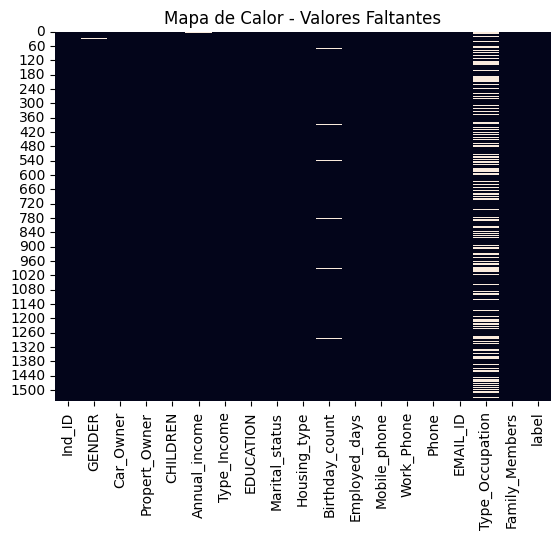

In [6]:
sns.heatmap(
    df.isnull(), cbar=False
)
plt.title('Mapa de Calor - Valores Faltantes')
plt.show()

### Imputación de valores nulos.
Para ello primero realizamos una validación si los datos, peresentan un alto coeficiente de variación.

En caso de presentar un Coeficiente de Variación > 30%, se imputaran los datos en base a la mediana.

[OK] la media para Annual_income es: 191399.326
[OK] la mediana para Annual_income es: 166500.0
[OK] el coeficiente de variacion para Annual_income es: 0.592


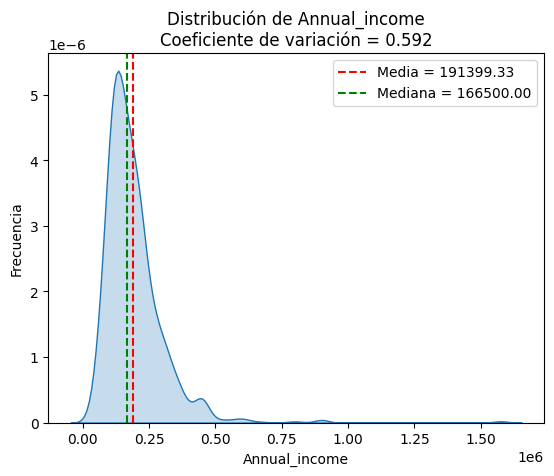

In [7]:
u_annual_income = round(df['Annual_income'].mean(), 3)
Med_annual_income = df['Annual_income'].median()
cv_annual_income = round(df['Annual_income'].std() / u_annual_income, 3)
print(f'[OK] la media para Annual_income es: {u_annual_income}')
print(f'[OK] la mediana para Annual_income es: {Med_annual_income}')
print(f'[OK] el coeficiente de variacion para Annual_income es: {cv_annual_income}')

sns.kdeplot(data=df['Annual_income'], fill=True,  linewidth=1)

plt.axvline(u_annual_income, color='red', linestyle='--', label=f'Media = {u_annual_income:.2f}')
plt.axvline(Med_annual_income, color='green', linestyle='--', label=f'Mediana = {Med_annual_income:.2f}')

plt.title(f'Distribución de Annual_income\nCoeficiente de variación = {cv_annual_income:.3f}')
plt.xlabel('Annual_income')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

[OK] la media para Birthday_count es: -16040.342
[OK] la mediana para Birthday_count es: -15661.5
[OK] el coeficiente de variacion para Birthday_count es: -0.264


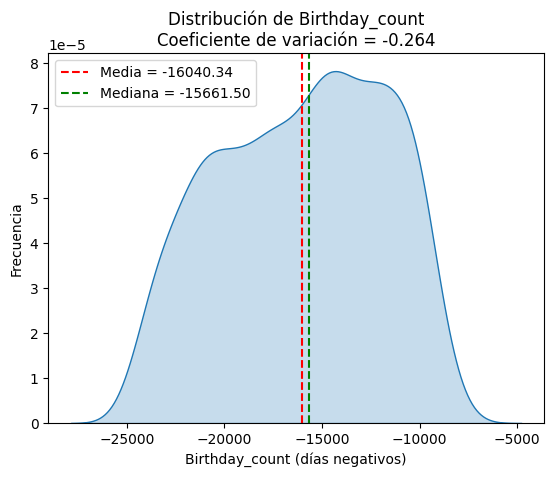

In [8]:
u_birthday_count = round(df['Birthday_count'].mean(), 3)
Med_birthday_count = df['Birthday_count'].median()
cv_birthday_count = round(df['Birthday_count'].std() / u_birthday_count, 3)
print(f'[OK] la media para Birthday_count es: {u_birthday_count}')
print(f'[OK] la mediana para Birthday_count es: {Med_birthday_count}')
print(f'[OK] el coeficiente de variacion para Birthday_count es: {cv_birthday_count}')

sns.kdeplot(data=df['Birthday_count'], fill=True,  linewidth=1)

plt.axvline(u_birthday_count, color='red', linestyle='--', label=f'Media = {u_birthday_count:.2f}')
plt.axvline(Med_birthday_count, color='green', linestyle='--', label=f'Mediana = {Med_birthday_count:.2f}')

plt.title(f'Distribución de Birthday_count\nCoeficiente de variación = {cv_birthday_count:.3f}')
plt.xlabel("Birthday_count (días negativos)")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

### Imputación de valoren nulos.
Realizaremos la imputación en base al valor de la media a la columna cuantitativa continua.

A la otra columna con valores faltantes al ser cualitatitiva se imputara con el valor "Desconocido".

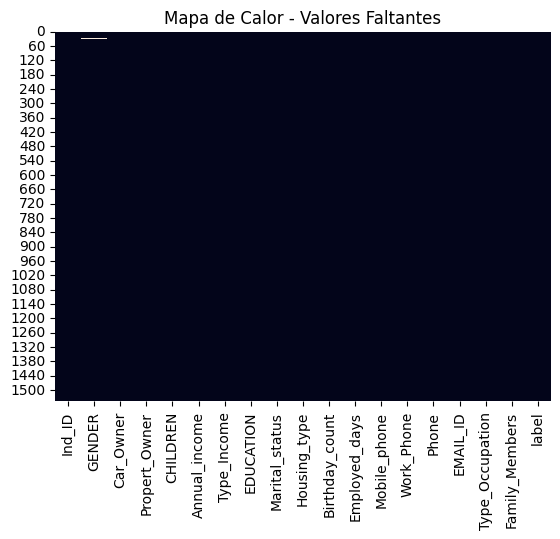

In [9]:
df['Annual_income'] = df['Annual_income'].fillna(u_annual_income)
df['Birthday_count'] = df['Birthday_count'].fillna(u_birthday_count)
df['Type_Occupation'] = df['Type_Occupation'].fillna('Desconocido')

sns.heatmap(
    df.isnull(), cbar=False
)
plt.title('Mapa de Calor - Valores Faltantes')
plt.show()

### Construcción de la data procesada para el modelo.
En este escenario al ver las cualidades de la información y el requerimiento, utilizaremos un modelo de Regresión Logistica el cual es el indicado para ayudarnos a predcir entre valores binarios, para clasificar a los clientes.

1. Eliminamos columna no predictoria, ya que es el identificador único por cliente.

In [10]:
df = df.drop(columns=['Ind_ID'])

2. Codificamos las columnas Cualitativas para generar el entrenamiento del modelo.

In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'),
             ['GENDER','Car_Owner','Propert_Owner','Type_Income','EDUCATION','Marital_status','Housing_type','Type_Occupation']
        ),
        ('num', 'passthrough',
             ['CHILDREN','Annual_income','Birthday_count','Employed_days','Mobile_phone','Work_Phone','Phone','EMAIL_ID','Family_Members']
        )
    ]
)

3. Separamos variables predictorias y objetivo

In [12]:
X = df.drop(columns=['label'])
Y = df['label']

4. División de entrenamiento y prueba

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42, stratify=Y
)

5. Crear pipeline completo

In [14]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1_000, solver='lbfgs', class_weight='balanced'))
])

6. Entrenar el modelo

In [15]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


7. Evaluar desempeño

Matriz de confusión:
 [[412   0]
 [ 53   0]]
Reporte de clasificación:
               precision    recall  f1-score   support

       False       0.89      1.00      0.94       412
        True       0.00      0.00      0.00        53

    accuracy                           0.89       465
   macro avg       0.44      0.50      0.47       465
weighted avg       0.79      0.89      0.83       465

AUC: 0.47529309397325514


C:\hdfs\PRUEBA_TECNITA_ITAU\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\hdfs\PRUEBA_TECNITA_ITAU\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\hdfs\PRUEBA_TECNITA_ITAU\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


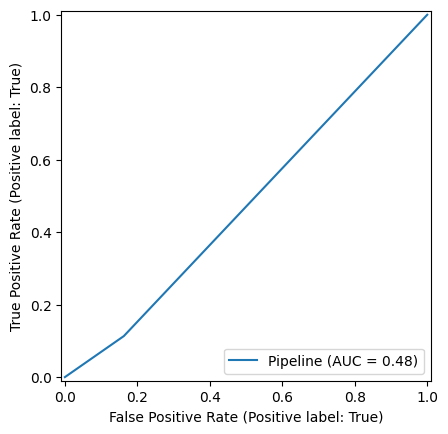

In [18]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print('Matriz de confusión:\n', confusion_matrix(y_test, y_pred))
print('Reporte de clasificación:\n', classification_report(y_test, y_pred))
print('AUC:', roc_auc_score(y_test, y_prob))

RocCurveDisplay.from_estimator(model, X_test, y_test)

# Conclusión:

La Data se encuentra desbalanceada, por lo cual el modelo de Regresión Logistica predice todo como 0 y no logra aprender de los clientes que si utilizan la tarjeta (1).

Por lo cual debemos explorar metodos de Rebalanceo de la muestra (Oversampling o Undersampling).